In [1]:
import numpy as np
import geopandas as gpd
import rasterio as rio
from rasterio.mask import mask
from rasterio.windows import Window
from glob import glob
from pathlib import Path
from datetime import datetime
from tqdm import tqdm
import warnings

In [2]:
def _parse_dates_from_name(path_str):
    # Assumes name like: S2_YYYY-MM-DD_YYYY-MM-DD...veloc_x.tif
    name = Path(path_str).name
    dates = name[3:24]

    start_date = datetime.strptime(dates[:10], "%Y-%m-%d")
    end_date = datetime.strptime(dates[11:], "%Y-%m-%d")

    return dates, start_date, end_date, (end_date - start_date)


def _valid_period_months(period):
    period = period.upper()

    if period == "ALL":
        return None
    elif period == "NDJFM":
        return {11, 12, 1, 2, 3}
    elif period == "MJJAS":
        return {5, 6, 7, 8, 9}
    else:
        raise ValueError(
            "Invalid period. Expected one of: 'all', 'NDJFM', or 'MJJAS'."
        )


def _pair_in_period(start_date, end_date, period):
    months = _valid_period_months(period)

    if months is None:
        return True

    return start_date.month in months and end_date.month in months


def _collect_pairs(data_dir, period="all"):
    _valid_period_months(period)

    xs = sorted(glob(f"{data_dir}/*/S2*veloc_x.tif"))
    ys = sorted(glob(f"{data_dir}/*/S2*veloc_y.tif"))

    x_by_key = {}
    y_by_key = {}

    for p in xs:
        key, start_date, end_date, _ = _parse_dates_from_name(p)
        if _pair_in_period(start_date, end_date, period):
            x_by_key[key] = p

    for p in ys:
        key, start_date, end_date, _ = _parse_dates_from_name(p)
        if _pair_in_period(start_date, end_date, period):
            y_by_key[key] = p

    common = sorted(set(x_by_key).intersection(y_by_key))

    if not common:
        raise ValueError(
            f"No matching veloc_x / veloc_y date pairs found for period={period!r}."
        )

    pairs = []
    for key in common:
        start_date, end_date = _parse_dates_from_name(x_by_key[key])[1:3]
        pairs.append(
            {
                "key": key,
                "x_path": x_by_key[key],
                "y_path": y_by_key[key],
                "start_date": start_date,
                "end_date": end_date,
            }
        )

    return pairs


def _read_window_as_float32(src, window):
    arr = src.read(1, window=window, masked=True).astype("float32")
    arr = arr.filled(np.nan)

    # Also handle explicit nodata values in case they were not masked
    if src.nodata is not None:
        arr[arr == src.nodata] = np.nan

    return arr


def _nanmedian(arr, axis=0):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        return np.nanmedian(arr, axis=axis).astype("float32")


def _nmad_from_stack(stack):
    """
    stack shape: dates, y, x
    """
    med = _nanmedian(stack, axis=0)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        mad = np.nanmedian(np.abs(stack - med[None, :, :]), axis=0)

    return (1.4826 * mad).astype("float32")


def _write_arr(dst, arr, window, nodata):
    out = arr.astype("float32", copy=False)
    out = np.where(np.isfinite(out), out, nodata).astype("float32", copy=False)
    dst.write(out, 1, window=window)


def _stable_median(path, stable_gdf):
    """
    Median over stable polygon for one raster.
    Reads only the polygon bounding region, not the full raster.
    """
    with rio.open(path) as src:
        stable = stable_gdf.to_crs(src.crs)

        out, _ = mask(
            src,
            stable.geometry,
            crop=True,
            filled=False,
            indexes=1,
        )

        arr = out.astype("float32").filled(np.nan)

        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan

        med = np.nanmedian(arr)

    if not np.isfinite(med):
        raise ValueError(
            f"Could not calculate stable median for {path}. "
            "Stable polygon may not overlap valid data."
        )

    return float(med)


def _check_same_grid(paths, ref_path):
    with rio.open(ref_path) as ref:
        ref_crs = ref.crs
        ref_transform = ref.transform
        ref_width = ref.width
        ref_height = ref.height

    for p in paths:
        with rio.open(p) as src:
            if src.crs != ref_crs:
                raise ValueError(f"CRS mismatch: {p}")

            if src.transform != ref_transform:
                raise ValueError(f"Transform mismatch: {p}")

            if src.width != ref_width or src.height != ref_height:
                raise ValueError(f"Shape mismatch: {p}")


def _window_grid(width, height, block_size):
    for row_off in range(0, height, block_size):
        win_h = min(block_size, height - row_off)

        for col_off in range(0, width, block_size):
            win_w = min(block_size, width - col_off)

            yield Window(
                col_off=col_off,
                row_off=row_off,
                width=win_w,
                height=win_h,
            )


def process_velocity_medians(
    data_dir,
    stable_shp,
    out_dir,
    period="all",
    block_size=512,
    nodata=-9999.0,
    check_grids=True,
):
    """
    Memory-efficient median/NMAD calculation for many feature-tracking velocity rasters.

    Does:
      1. Finds matching veloc_x / veloc_y rasters.
      2. Computes stable-area median offset for each pair and component.
      3. Processes rasters block-by-block.
      4. Writes median EW, median NS, NMAD EW, NMAD NS, and median horizontal velocity.

    This avoids loading the full date stack into memory.
    """

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    stable_gdf = gpd.read_file(stable_shp)
    pairs = _collect_pairs(data_dir, period=period)

    print(f"Found {len(pairs)} matching velocity pairs for period={period!r}.")

    all_paths = []
    for pair in pairs:
        all_paths.extend([pair["x_path"], pair["y_path"]])

    ref_path = pairs[0]["x_path"]

    if check_grids:
        print("Checking that all rasters share the same grid...")
        _check_same_grid(all_paths, ref_path)

    # Compute stable offsets once per raster.
    print("Calculating stable-area offsets...")
    for pair in tqdm(pairs):
        pair["x_stable_offset"] = _stable_median(pair["x_path"], stable_gdf)
        pair["y_stable_offset"] = _stable_median(pair["y_path"], stable_gdf)

    with rio.open(ref_path) as ref:
        profile = ref.profile.copy()
        width = ref.width
        height = ref.height

    profile.update(
        driver="GTiff",
        count=1,
        dtype="float32",
        nodata=nodata,
        compress="deflate",
        predictor=3,
        tiled=True,
        blockxsize=512,
        blockysize=512,
        BIGTIFF="IF_SAFER",
    )

    # Remove any inherited profile fields that can conflict with writing
    profile.pop("photometric", None)
    profile.pop("interleave", None)

    out_median_ns = out_dir / f"S2_{period}_median_ns_velocity.tif"
    out_nmad_ns = out_dir / f"S2_{period}_nmad_ns_velocity.tif"
    out_median_ew = out_dir / f"S2_{period}_median_ew_velocity.tif"
    out_nmad_ew = out_dir / f"S2_{period}_nmad_ew_velocity.tif"
    out_median_horizontal = out_dir / f"S2_{period}_median_horizontal_velocity.tif"

    windows = list(_window_grid(width, height, block_size))

    print(f"Processing {len(windows)} windows with block_size={block_size}...")

    with (
        rio.open(out_median_ns, "w", **profile) as dst_med_ns,
        rio.open(out_nmad_ns, "w", **profile) as dst_nmad_ns,
        rio.open(out_median_ew, "w", **profile) as dst_med_ew,
        rio.open(out_nmad_ew, "w", **profile) as dst_nmad_ew,
        rio.open(out_median_horizontal, "w", **profile) as dst_med_h,
    ):
        for window in tqdm(windows):
            ew_stack = []
            ns_stack = []

            for pair in pairs:
                with rio.open(pair["x_path"]) as src_x:
                    ew = _read_window_as_float32(src_x, window)
                    ew = ew - pair["x_stable_offset"]

                with rio.open(pair["y_path"]) as src_y:
                    ns = _read_window_as_float32(src_y, window)
                    ns = ns - pair["y_stable_offset"]

                ew_stack.append(ew)
                ns_stack.append(ns)

            ew_stack = np.stack(ew_stack, axis=0)
            ns_stack = np.stack(ns_stack, axis=0)

            median_ew = _nanmedian(ew_stack, axis=0)
            median_ns = _nanmedian(ns_stack, axis=0)

            nmad_ew = _nmad_from_stack(ew_stack)
            nmad_ns = _nmad_from_stack(ns_stack)

            median_horizontal = np.sqrt(median_ew**2 + median_ns**2).astype("float32")

            _write_arr(dst_med_ew, median_ew, window, nodata)
            _write_arr(dst_med_ns, median_ns, window, nodata)
            _write_arr(dst_nmad_ew, nmad_ew, window, nodata)
            _write_arr(dst_nmad_ns, nmad_ns, window, nodata)
            _write_arr(dst_med_h, median_horizontal, window, nodata)

    print("Done.")
    print(out_median_ns)
    print(out_nmad_ns)
    print(out_median_ew)
    print(out_nmad_ew)
    print(out_median_horizontal)

In [3]:
period = "all"

process_velocity_medians(
    data_dir="/mnt/storage/brencher/repos/jirp_nisar_eval/data/S2_ft",
    stable_shp="polygons/ji_stable.shp",
    out_dir="../products/feature_tracking",
    period=period,
    block_size=2048,
)

Found 285 matching velocity pairs for period='all'.
Checking that all rasters share the same grid...
Calculating stable-area offsets...


100%|█████████████████████████████████████████████████████████████████████████████████| 285/285 [04:43<00:00,  1.01it/s]


Processing 12 windows with block_size=2048...


100%|████████████████████████████████████████████████████████████████████████████████| 12/12 [1:01:51<00:00, 309.31s/it]

Done.
../products/feature_tracking/S2_all_median_ns_velocity.tif
../products/feature_tracking/S2_all_nmad_ns_velocity.tif
../products/feature_tracking/S2_all_median_ew_velocity.tif
../products/feature_tracking/S2_all_nmad_ew_velocity.tif
../products/feature_tracking/S2_all_median_horizontal_velocity.tif


In [ ]:
period = 'all'
ds = combine_veloc(f'/mnt/storage/brencher/repos/jirp_nisar_eval/data/S2_ft', period)

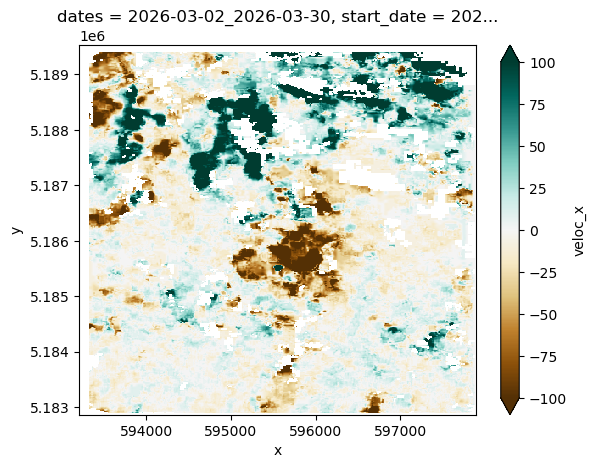

In [5]:
(ds.isel(dates=-1).veloc_ew).plot.imshow(vmin=-100, vmax=100, cmap='BrBG')

In [6]:
ds = ds - ds.rio.clip(stable_gdf.geometry).median(dim=['x', 'y'])

In [ ]:
median_ew = ds.veloc_ew.median(dim='dates')
median_ns = ds.veloc_ns.median(dim='dates')

In [ ]:
def nmad(da: xr.DataArray, dim: str | list[str] = None) -> xr.DataArray:
    med = da.median(dim=dim, skipna=True)
    mad = (np.abs(da - med)).median(dim=dim, skipna=True)
    return 1.4826 * mad

In [ ]:
nmad_ew = nmad(ds.veloc_ew, dim='dates')
nmad_ns = nmad(ds.veloc_ns, dim='dates')

In [ ]:
(median_ew.isel(x=slice(2000, 4000), y=slice(2000, 4000))).plot.imshow(vmin= -200, vmax=200, cmap='BrBG')

In [ ]:
(nmad_ew.isel(x=slice(2000, 4000), y=slice(2000, 4000))).plot.imshow(vmin= 0, vmax=100, cmap='cividis')

In [ ]:
(median_ns.isel(x=slice(2000, 4000), y=slice(2000, 4000))).plot.imshow(vmin= -200, vmax=200, cmap='PRGn')

In [ ]:
(nmad_ns.isel(x=slice(2000, 4000), y=slice(2000, 4000))).plot.imshow(vmin=0, vmax=100, cmap='cividis')

In [13]:
median_horizontal = np.sqrt(median_ew**2 + median_ns**2)

In [15]:
nmad(median_horizontal.rio.clip(stable_gdf.geometry), dim=['x', 'y'])

<xarray.DataArray ()> Size: 8B
array(6.02046068)
Coordinates:
    spatial_ref  int64 8B 0

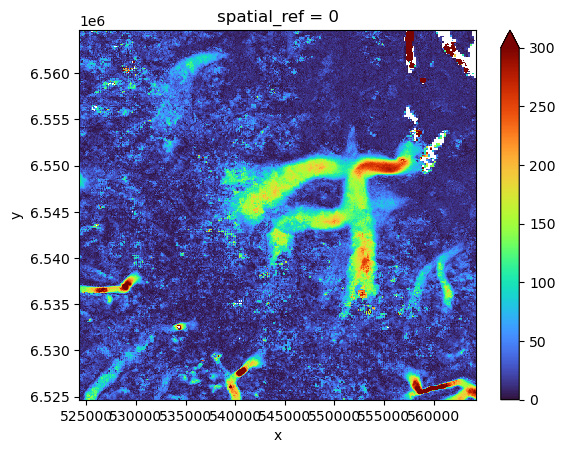

In [14]:
median_horizontal.isel(x=slice(2000, 4000), y=slice(2000, 4000)).plot.imshow(vmin= 0, vmax=300, cmap='turbo')

In [17]:
median_ns.rio.to_raster(f'../products/nisqually/S2_{period}_median_ns_velocity.tif')
nmad_ns.rio.to_raster(f'../products/nisqually/S2_{period}_nmad_ns_velocity.tif')
median_ew.rio.to_raster(f'../products/nisqually/S2_{period}_median_ew_velocity.tif')
nmad_ew.rio.to_raster(f'../products/nisqually/S2_{period}_nmad_ew_velocity.tif')
median_horizontal.rio.to_raster(f'../products/nisqually/S2_{period}_median_horizontal_velocity.tif')

## confidence intervals

In [18]:
# from joblib import Parallel, delayed

# def _one_boot(idx, X, Y):
#     with np.errstate(invalid="ignore"):
#         m_vx = np.nanmedian(X[idx, :], axis=0)
#         m_vy = np.nanmedian(Y[idx, :], axis=0)
#     spd = np.hypot(m_vx, m_vy)
#     return m_vx.astype(np.float32), m_vy.astype(np.float32), spd.astype(np.float32)

# def bootstrap_median_ci_components_and_speed_parallel(
#     vx: xr.DataArray,
#     vy: xr.DataArray,
#     n_boot: int = 1000,
#     seed: int | None = 0,
#     n_jobs: int = 8,   # adjust for your cores/RAM
# ) -> xr.Dataset:
#     vx, vy = xr.align(vx, vy, join="exact")
#     vx2 = vx.transpose("dates", ...).stack(pixel=("y","x"))
#     vy2 = vy.transpose("dates", ...).stack(pixel=("y","x"))
#     X = np.asarray(vx2.data)  # (n_dates, n_pix)
#     Y = np.asarray(vy2.data)
#     n_dates, n_pix = X.shape

#     rng = np.random.default_rng(seed)
#     idxs = rng.integers(0, n_dates, size=(n_boot, n_dates), endpoint=False)

#     results = Parallel(n_jobs=n_jobs, prefer="processes")(
#         delayed(_one_boot)(idxs[b], X, Y) for b in range(n_boot)
#     )
#     boot_vx = np.stack([r[0] for r in results], axis=0)  # (n_boot, n_pix), float32
#     boot_vy = np.stack([r[1] for r in results], axis=0)
#     boot_sp = np.stack([r[2] for r in results], axis=0)

#     k_low  = max(0, int(np.floor(0.025 * n_boot)) - 1)
#     k_high = min(n_boot - 1, int(np.ceil(0.975 * n_boot)) - 1)

#     vx_low  = np.partition(boot_vx, k_low,  axis=0)[k_low,  :]
#     vx_high = np.partition(boot_vx, k_high, axis=0)[k_high, :]
#     vy_low  = np.partition(boot_vy, k_low,  axis=0)[k_low,  :]
#     vy_high = np.partition(boot_vy, k_high, axis=0)[k_high, :]
#     sp_low  = np.partition(boot_sp, k_low,  axis=0)[k_low,  :]
#     sp_high = np.partition(boot_sp, k_high, axis=0)[k_high, :]

#     pixel = vx2.coords["pixel"]
#     def unstack(name, arr):
#         return xr.DataArray(arr, coords={"pixel": pixel}, dims=("pixel",)).unstack("pixel").rename(name)

#     return xr.Dataset(
#         {
#             "vx_ci_low":  unstack("vx_ci_low",  vx_low),
#             "vx_ci_high": unstack("vx_ci_high", vx_high),
#             "vy_ci_low":  unstack("vy_ci_low",  vy_low),
#             "vy_ci_high": unstack("vy_ci_high", vy_high),
#             "spd_ci_low": unstack("spd_ci_low", sp_low),
#             "spd_ci_high":unstack("spd_ci_high", sp_high),
#         }
#     )

In [19]:
# stats_ds = bootstrap_median_ci_components_and_speed_parallel(ds.veloc_ew, ds.veloc_ns, n_boot=1000, seed=42, n_jobs = 8)

In [20]:
# stats_ds.vx_ci_high.rio.to_raster('../products/S2_MJJAS_ci_high_ew_velocity.tif')
# stats_ds.vx_ci_low.rio.to_raster('../products/S2_MJJAS_ci_low_ew_velocity.tif')
# (stats_ds.vx_ci_high - stats_ds.vx_ci_low).rio.to_raster('../products/S2_MJJAS_ci_interval_ew_velocity.tif')

# stats_ds.vy_ci_high.rio.to_raster('../products/S2_MJJAS_ci_high_ns_velocity.tif')
# stats_ds.vy_ci_low.rio.to_raster('../products/S2_MJJAS_ci_low_ns_velocity.tif')
# (stats_ds.vy_ci_high - stats_ds.vy_ci_low).rio.to_raster('../products/S2_MJJAS_ci_interval_ns_velocity.tif')

# stats_ds.spd_ci_high.rio.to_raster('../products/S2_MJJAS_ci_high_horizontal_velocity.tif')
# stats_ds.spd_ci_low.rio.to_raster('../products/S2_MJJAS_ci_low_horizontal_velocity.tif')
# (stats_ds.spd_ci_high - stats_ds.spd_ci_low).rio.to_raster('../products/S2_MJJAS_ci_interval_horizontal_velocity.tif')